# 04 — Drive-Level Evaluation and Operational Threshold Analysis

This notebook converts the **Logistic Regression out-of-fold (OOF) drive-day predictions** produced by Notebook 03 into operational, physical-drive-level results.

**No model is retrained here.** The purpose is to answer a different question from row-level model validation: if a storage team acts on model alerts, how many unique drives would be investigated, how many failures would be caught, and how much advance warning would be available?

## Input contract

Notebook 03 must provide `logistic_oof_with_drive_info.parquet` with:

- `fold`
- `serial_number`
- `date`
- `y_true`
- `y_prob`

## Questions answered

For each candidate threshold:

- How many **unique drives** are alerted?
- How many failed drives are detected or missed?
- How many healthy drives are falsely alerted?
- What are drive-level precision, recall, and F1?
- For detected failed drives, how early does the first valid alert occur before failure?

The notebook also exports three CSV artifacts for downstream interpretation and error analysis.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## 1. Configuration

The four thresholds below are the operating points carried forward from the earlier row-level threshold analysis. They are evaluated here at the **unique-drive level**, not re-optimized.

The preferred balanced operating point from the historical analysis is `0.70`; `0.35` and `0.90` are retained as higher-recall and lower-alert alternatives.


In [2]:
INPUT_FILENAME = "logistic_oof_with_drive_info.parquet"

CANDIDATE_THRESHOLDS = [
    0.35,  # high-recall candidate from row-level analysis
    0.70,  # balanced candidate
    0.75,  # alternate balanced candidate
    0.90,  # lower-alert candidate
]

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_THRESHOLD_OUTPUT = OUTPUT_DIR / "drive_level_threshold_analysis.csv"
LEAD_TIME_OUTPUT = OUTPUT_DIR / "drive_level_lead_time_summary.csv"
FAILED_DRIVE_DETAIL_OUTPUT = OUTPUT_DIR / "failed_drive_alert_details.csv"

REQUIRED_COLUMNS = {
    "fold",
    "serial_number",
    "date",
    "y_true",
    "y_prob",
}

## 2. Locate and load the OOF parquet

In [3]:
def find_input_file(filename: str) -> Path:
    """Locate the canonical Notebook 03 parquet in Kaggle or local environments."""
    candidates = [
        Path("/kaggle/working") / filename,
        Path("/mnt/data") / filename,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Kaggle datasets are mounted under /kaggle/input/<dataset-name>/.
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        exact_matches = list(kaggle_input.rglob(filename))
        if exact_matches:
            if len(exact_matches) > 1:
                print("Multiple exact matches found. Using the first:")
                for match in exact_matches:
                    print("  ", match)
            return exact_matches[0]

        # Helpful fallback when a downloaded/uploaded copy has a suffix such as '(2)'.
        stem = Path(filename).stem
        suffix = Path(filename).suffix
        fallback_matches = list(kaggle_input.rglob(f"{stem}*{suffix}"))
        if fallback_matches:
            print("Canonical filename not found; using compatible parquet:")
            for match in fallback_matches:
                print("  ", match)
            return fallback_matches[0]

    # Same suffix-tolerant fallback for local review.
    local_fallbacks = list(Path("/mnt/data").glob("logistic_oof_with_drive_info*.parquet"))
    if local_fallbacks:
        print("Canonical filename not found; using local compatible parquet:", local_fallbacks[0])
        return local_fallbacks[0]

    raise FileNotFoundError(
        f"Could not find {filename!r} in /kaggle/working, /kaggle/input, or /mnt/data."
    )


input_path = find_input_file(INPUT_FILENAME)
print("Loading:", input_path)

df = pd.read_parquet(input_path)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()


Canonical filename not found; using compatible parquet:
   /kaggle/input/datasets/emilywanglovescats/logistic-oof-with-drive-info/logistic_oof_with_drive_info (2).parquet
Loading: /kaggle/input/datasets/emilywanglovescats/logistic-oof-with-drive-info/logistic_oof_with_drive_info (2).parquet
Rows: 7,437,300
Columns: ['fold', 'serial_number', 'date', 'y_true', 'y_prob']


,fold,serial_number,date,y_true,y_prob
0,3,ZL2CRHCN,2023-12-09,0,0.338518
1,4,AAHM4H6H,2023-10-07,0,0.334823
2,1,ZTT3VRWC,2023-10-25,0,0.347042
3,2,X0GDJXLC,2023-11-29,0,0.342460
4,0,ZL2LMGEK,2023-12-13,0,0.334120


## 3. Input and leakage-structure checks

Before drive-level aggregation, verify that the Notebook 03 artifact is structurally usable. In particular, each `serial_number` should appear in only one OOF fold because `serial_number` was the grouping variable in `StratifiedGroupKFold`.


In [4]:
missing_columns = REQUIRED_COLUMNS - set(df.columns)
if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

df = df[
    ["fold", "serial_number", "date", "y_true", "y_prob"]
].copy()

if df[["fold", "serial_number", "date", "y_true", "y_prob"]].isna().any().any():
    null_counts = df[
        ["fold", "serial_number", "date", "y_true", "y_prob"]
    ].isna().sum()
    raise ValueError(
        "Missing values found in required fields:\n"
        f"{null_counts[null_counts > 0]}"
    )

df["date"] = pd.to_datetime(df["date"], errors="raise")

unique_labels = set(df["y_true"].unique())
if not unique_labels.issubset({0, 1}):
    raise ValueError(
        f"y_true must contain only 0/1. Found: {sorted(unique_labels)}"
    )

if not df["y_prob"].between(0, 1).all():
    raise ValueError("y_prob contains values outside [0, 1].")

# Because serial_number was the grouping variable in StratifiedGroupKFold,
# each drive should belong to one OOF fold only.
folds_per_drive = df.groupby("serial_number")["fold"].nunique()
if folds_per_drive.max() != 1:
    bad_count = int((folds_per_drive > 1).sum())
    raise ValueError(
        f"{bad_count:,} drives appear in more than one fold. "
        "This violates the expected grouped-CV structure."
    )

duplicate_drive_dates = df.duplicated(
    subset=["serial_number", "date"]
).sum()

if duplicate_drive_dates > 0:
    warnings.warn(
        f"Found {duplicate_drive_dates:,} duplicate serial_number/date rows. "
        "The notebook can still run, but inspect them if this is unexpected."
    )

print("Sanity checks passed.")
print(f"Unique drives: {df['serial_number'].nunique():,}")
print(f"Positive rows: {int(df['y_true'].sum()):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Folds: {sorted(df['fold'].unique().tolist())}")
print(f"Duplicate drive-date rows: {duplicate_drive_dates:,}")

Sanity checks passed.
Unique drives: 281,192
Positive rows: 324
Date range: 2023-10-01 to 2023-12-31
Folds: [0, 1, 2, 3, 4]
Duplicate drive-date rows: 0


## 4. Establish each drive's outcome and failure date

A drive is considered a **failed drive** when it has at least one row with `y_true = 1`.

For failed drives, the failure date is the earliest date at which `y_true = 1`.

For operational evaluation, an alert on a failed drive counts as a successful detection only when it occurs **on or before the failure date**. This prevents a post-failure score from being credited as an early warning.

In [5]:
failed_rows = df.loc[
    df["y_true"].eq(1),
    ["serial_number", "date"],
].copy()

failure_dates = (
    failed_rows
    .groupby("serial_number", as_index=False)
    .agg(failure_date=("date", "min"))
)

drive_base = (
    df.groupby("serial_number", as_index=False)
    .agg(
        fold=("fold", "first"),
        first_observation_date=("date", "min"),
        last_observation_date=("date", "max"),
        max_score_any_date=("y_prob", "max"),
        row_count=("y_true", "size"),
        actually_failed=("y_true", "max"),
    )
    .merge(
        failure_dates,
        on="serial_number",
        how="left",
        validate="one_to_one",
    )
)

drive_base["actually_failed"] = drive_base["actually_failed"].astype(int)

failed_drive_count = int(drive_base["actually_failed"].sum())
healthy_drive_count = int((drive_base["actually_failed"] == 0).sum())

print(f"Total unique drives: {len(drive_base):,}")
print(f"Failed drives: {failed_drive_count:,}")
print(f"Healthy drives: {healthy_drive_count:,}")

if drive_base.loc[
    drive_base["actually_failed"].eq(1), "failure_date"
].isna().any():
    raise AssertionError("A failed drive is missing its failure date.")

drive_base.head()

Total unique drives: 281,192
Failed drives: 324
Healthy drives: 280,868


,serial_number,fold,first_observation_date,last_observation_date,max_score_any_date,row_count,actually_failed,failure_date
0,000a43e7dee60010,0,2023-10-02,2023-12-29,0.334120,27,0,NaT
1,00ac486b9bec0010,3,2023-10-19,2023-12-22,0.338518,21,0,NaT
2,01b776caeb6a0010,1,2023-10-03,2023-12-31,0.347042,39,0,NaT
3,02308a3415be0010,4,2023-10-02,2023-12-25,0.334823,27,0,NaT
4,0394cd7bc5d00010,4,2023-10-02,2023-12-27,0.334823,24,0,NaT


## 5. Build the pre-failure scoring view

For failed drives, only observations on or before the failure date are eligible to count as warnings.

Healthy drives have no failure date, so all of their observations remain eligible when determining whether they were ever falsely alerted.

In [6]:
df_with_failure_date = df.merge(
    failure_dates,
    on="serial_number",
    how="left",
    validate="many_to_one",
)

eligible_mask = (
    df_with_failure_date["failure_date"].isna()
    | (df_with_failure_date["date"] <= df_with_failure_date["failure_date"])
)

eligible_df = df_with_failure_date.loc[eligible_mask].copy()

print(f"Rows before operational time filter: {len(df_with_failure_date):,}")
print(f"Rows eligible for alert evaluation: {len(eligible_df):,}")

# Every drive should retain at least one eligible row.
eligible_drive_count = eligible_df["serial_number"].nunique()
if eligible_drive_count != drive_base["serial_number"].nunique():
    raise AssertionError(
        "Some drives disappeared after applying the pre-failure filter."
    )

Rows before operational time filter: 7,437,300
Rows eligible for alert evaluation: 7,437,299


## 6. Evaluate candidate thresholds at the physical-drive level

For each threshold, every physical drive contributes **exactly once** to the operational confusion matrix:

- **TP:** failed drive with at least one eligible alert on/before failure
- **FN:** failed drive with no eligible alert
- **FP:** healthy drive with at least one alert
- **TN:** healthy drive with no alert

This is intentionally different from a row-level confusion matrix, where a single drive can contribute many observations.


In [7]:
def evaluate_drive_threshold(
    eligible_data: pd.DataFrame,
    drive_reference: pd.DataFrame,
    threshold: float,
):
    alerts = (
        eligible_data["y_prob"] >= threshold
    )

    first_alert_dates = (
        eligible_data.loc[alerts, ["serial_number", "date"]]
        .groupby("serial_number", as_index=False)
        .agg(first_alert_date=("date", "min"))
    )

    max_eligible_scores = (
        eligible_data
        .groupby("serial_number", as_index=False)
        .agg(max_eligible_score=("y_prob", "max"))
    )

    drive_eval = (
        drive_reference[
            [
                "serial_number",
                "fold",
                "actually_failed",
                "failure_date",
            ]
        ]
        .merge(
            max_eligible_scores,
            on="serial_number",
            how="left",
            validate="one_to_one",
        )
        .merge(
            first_alert_dates,
            on="serial_number",
            how="left",
            validate="one_to_one",
        )
    )

    drive_eval["alerted"] = (
        drive_eval["max_eligible_score"] >= threshold
    )

    failed = drive_eval["actually_failed"].eq(1)
    alerted = drive_eval["alerted"]

    tp = int((failed & alerted).sum())
    fn = int((failed & ~alerted).sum())
    fp = int((~failed & alerted).sum())
    tn = int((~failed & ~alerted).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0.0
    )

    unique_drives_alerted = tp + fp
    alert_rate = unique_drives_alerted / len(drive_eval)

    alerts_per_failed_drive_caught = (
        unique_drives_alerted / tp
        if tp > 0
        else np.inf
    )

    summary = {
        "threshold": threshold,
        "total_unique_drives": len(drive_eval),
        "failed_drives": int(failed.sum()),
        "healthy_drives": int((~failed).sum()),
        "unique_drives_alerted": unique_drives_alerted,
        "drive_alert_rate": alert_rate,
        "failed_drives_detected": tp,
        "failed_drives_missed": fn,
        "healthy_drives_falsely_alerted": fp,
        "healthy_drives_not_alerted": tn,
        "drive_precision": precision,
        "drive_recall": recall,
        "drive_f1": f1,
        "alerts_per_failed_drive_caught": alerts_per_failed_drive_caught,
    }

    return summary, drive_eval


threshold_summaries = []
drive_details_by_threshold = {}

for threshold in CANDIDATE_THRESHOLDS:
    summary, details = evaluate_drive_threshold(
        eligible_data=eligible_df,
        drive_reference=drive_base,
        threshold=threshold,
    )
    threshold_summaries.append(summary)
    drive_details_by_threshold[threshold] = details

drive_threshold_results = pd.DataFrame(threshold_summaries)

drive_threshold_results

,threshold,total_unique_drives,failed_drives,healthy_drives,unique_drives_alerted,drive_alert_rate,failed_drives_detected,failed_drives_missed,healthy_drives_falsely_alerted,healthy_drives_not_alerted,drive_precision,drive_recall,drive_f1,alerts_per_failed_drive_caught
0,0.35,281192,324,280868,6735,0.023952,228,96,6507,274361,0.033853,0.703704,0.064598,29.539474
1,0.70,281192,324,280868,2138,0.007603,152,172,1986,278882,0.071094,0.469136,0.123477,14.065789
2,0.75,281192,324,280868,2032,0.007226,149,175,1883,278985,0.073327,0.459877,0.126486,13.637584
3,0.90,281192,324,280868,1519,0.005402,133,191,1386,279482,0.087558,0.410494,0.144330,11.421053


### Readable threshold table

In [8]:
display_columns = [
    "threshold",
    "unique_drives_alerted",
    "drive_alert_rate",
    "failed_drives_detected",
    "failed_drives_missed",
    "healthy_drives_falsely_alerted",
    "drive_precision",
    "drive_recall",
    "drive_f1",
    "alerts_per_failed_drive_caught",
]

formatted = drive_threshold_results[display_columns].copy()

for column in [
    "drive_alert_rate",
    "drive_precision",
    "drive_recall",
    "drive_f1",
]:
    formatted[column] = formatted[column].map(lambda x: f"{x:.4%}")

formatted["alerts_per_failed_drive_caught"] = (
    formatted["alerts_per_failed_drive_caught"]
    .map(lambda x: f"{x:.1f}")
)

formatted

,threshold,unique_drives_alerted,drive_alert_rate,failed_drives_detected,failed_drives_missed,healthy_drives_falsely_alerted,drive_precision,drive_recall,drive_f1,alerts_per_failed_drive_caught
0,0.35,6735,2.3952%,228,96,6507,3.3853%,70.3704%,6.4598%,29.5
1,0.70,2138,0.7603%,152,172,1986,7.1094%,46.9136%,12.3477%,14.1
2,0.75,2032,0.7226%,149,175,1883,7.3327%,45.9877%,12.6486%,13.6
3,0.90,1519,0.5402%,133,191,1386,8.7558%,41.0494%,14.4330%,11.4


## 7. Lead-time analysis

For each detected failed drive:

`lead_time_days = failure_date - first_alert_date`

Interpretation:

- `0` days: first alert is on the failure date
- `1+` days: genuine advance warning
- larger values: earlier warning

We summarize both the amount of warning and the fraction of **all failed drives** detected at least 1, 3, and 7 days before failure.

In [9]:
lead_time_summaries = []
failed_drive_detail_frames = []

for threshold in CANDIDATE_THRESHOLDS:
    details = drive_details_by_threshold[threshold].copy()

    failed_details = details.loc[
        details["actually_failed"].eq(1)
    ].copy()

    failed_details["threshold"] = threshold
    failed_details["lead_time_days"] = (
        failed_details["failure_date"]
        - failed_details["first_alert_date"]
    ).dt.days

    detected = failed_details["alerted"]
    detected_details = failed_details.loc[detected].copy()

    # Because only on/before-failure rows were eligible, detected lead time
    # should never be negative.
    if (
        detected_details["lead_time_days"].dropna() < 0
    ).any():
        raise AssertionError("Negative lead time found unexpectedly.")

    total_failed = len(failed_details)
    detected_count = int(detected.sum())

    def pct_of_all_failed_at_least(days: int) -> float:
        count = int(
            (
                detected_details["lead_time_days"] >= days
            ).sum()
        )
        return count / total_failed if total_failed else np.nan

    lead_time_summaries.append(
        {
            "threshold": threshold,
            "total_failed_drives": total_failed,
            "detected_failed_drives": detected_count,
            "median_lead_time_days_detected": (
                detected_details["lead_time_days"].median()
                if detected_count
                else np.nan
            ),
            "mean_lead_time_days_detected": (
                detected_details["lead_time_days"].mean()
                if detected_count
                else np.nan
            ),
            "pct_all_failures_detected_same_day_or_earlier": (
                detected_count / total_failed
                if total_failed
                else np.nan
            ),
            "pct_all_failures_detected_at_least_1_day_early": (
                pct_of_all_failed_at_least(1)
            ),
            "pct_all_failures_detected_at_least_3_days_early": (
                pct_of_all_failed_at_least(3)
            ),
            "pct_all_failures_detected_at_least_7_days_early": (
                pct_of_all_failed_at_least(7)
            ),
        }
    )

    failed_drive_detail_frames.append(
        failed_details[
            [
                "threshold",
                "serial_number",
                "fold",
                "failure_date",
                "first_alert_date",
                "lead_time_days",
                "alerted",
                "max_eligible_score",
            ]
        ]
    )

lead_time_results = pd.DataFrame(lead_time_summaries)
failed_drive_alert_details = pd.concat(
    failed_drive_detail_frames,
    ignore_index=True,
)

lead_time_results

,threshold,total_failed_drives,detected_failed_drives,median_lead_time_days_detected,mean_lead_time_days_detected,pct_all_failures_detected_same_day_or_earlier,pct_all_failures_detected_at_least_1_day_early,pct_all_failures_detected_at_least_3_days_early,pct_all_failures_detected_at_least_7_days_early
0,0.35,324,228,22.5,28.640351,0.703704,0.623457,0.586420,0.524691
1,0.70,324,152,17.0,24.565789,0.469136,0.395062,0.367284,0.327160
2,0.75,324,149,17.0,24.637584,0.459877,0.388889,0.364198,0.327160
3,0.90,324,133,15.0,24.052632,0.410494,0.345679,0.317901,0.283951


### Readable lead-time summary

In [10]:
lead_formatted = lead_time_results.copy()

percentage_columns = [
    "pct_all_failures_detected_same_day_or_earlier",
    "pct_all_failures_detected_at_least_1_day_early",
    "pct_all_failures_detected_at_least_3_days_early",
    "pct_all_failures_detected_at_least_7_days_early",
]

for column in percentage_columns:
    lead_formatted[column] = lead_formatted[column].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else "NaN"
    )

for column in [
    "median_lead_time_days_detected",
    "mean_lead_time_days_detected",
]:
    lead_formatted[column] = lead_formatted[column].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else "NaN"
    )

lead_formatted

,threshold,total_failed_drives,detected_failed_drives,median_lead_time_days_detected,mean_lead_time_days_detected,pct_all_failures_detected_same_day_or_earlier,pct_all_failures_detected_at_least_1_day_early,pct_all_failures_detected_at_least_3_days_early,pct_all_failures_detected_at_least_7_days_early
0,0.35,324,228,22.50,28.64,70.37%,62.35%,58.64%,52.47%
1,0.70,324,152,17.00,24.57,46.91%,39.51%,36.73%,32.72%
2,0.75,324,149,17.00,24.64,45.99%,38.89%,36.42%,32.72%
3,0.90,324,133,15.00,24.05,41.05%,34.57%,31.79%,28.40%


## 8. Operational comparison plots

These plots compare candidate operating points. They are not used to train or optimize the model.

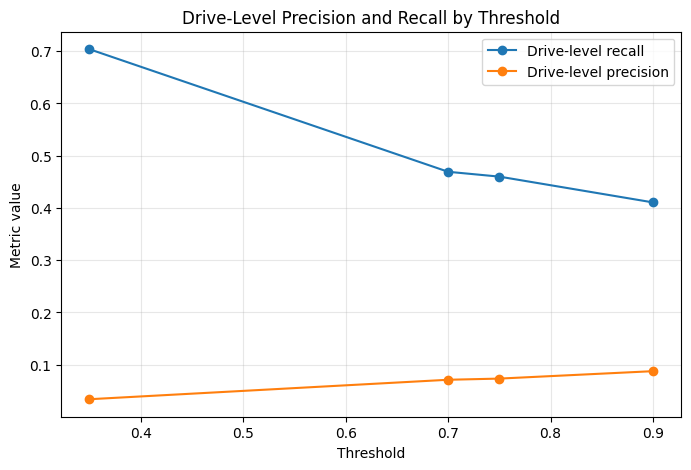

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    drive_threshold_results["threshold"],
    drive_threshold_results["drive_recall"],
    marker="o",
    label="Drive-level recall",
)
plt.plot(
    drive_threshold_results["threshold"],
    drive_threshold_results["drive_precision"],
    marker="o",
    label="Drive-level precision",
)
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Drive-Level Precision and Recall by Threshold")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

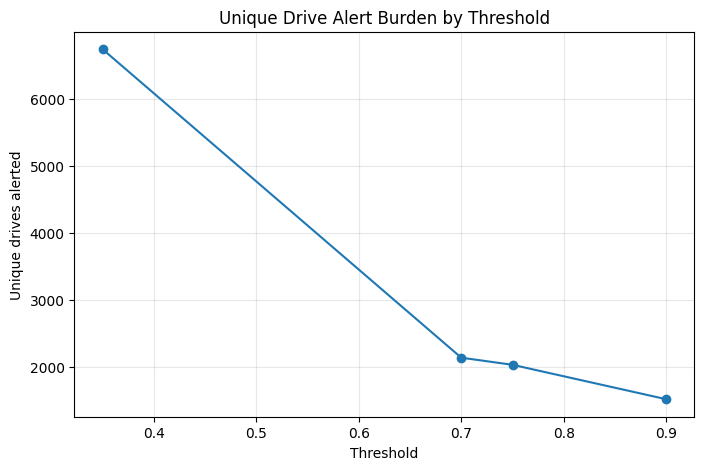

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    drive_threshold_results["threshold"],
    drive_threshold_results["unique_drives_alerted"],
    marker="o",
)
plt.xlabel("Threshold")
plt.ylabel("Unique drives alerted")
plt.title("Unique Drive Alert Burden by Threshold")
plt.grid(alpha=0.3)
plt.show()

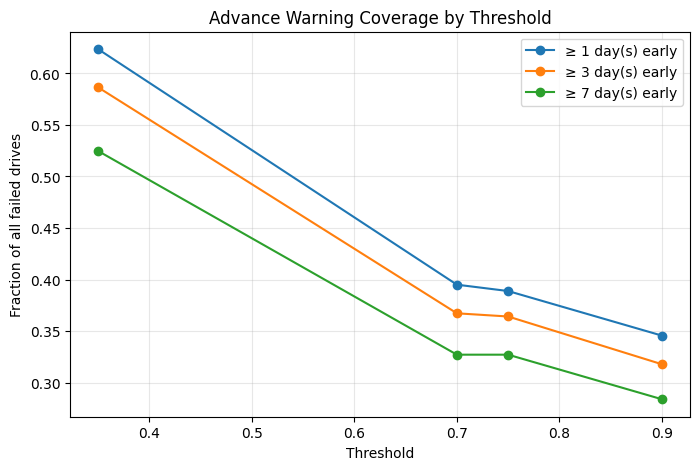

In [13]:
plt.figure(figsize=(8, 5))

for days, column in [
    (1, "pct_all_failures_detected_at_least_1_day_early"),
    (3, "pct_all_failures_detected_at_least_3_days_early"),
    (7, "pct_all_failures_detected_at_least_7_days_early"),
]:
    plt.plot(
        lead_time_results["threshold"],
        lead_time_results[column],
        marker="o",
        label=f"≥ {days} day(s) early",
    )

plt.xlabel("Threshold")
plt.ylabel("Fraction of all failed drives")
plt.title("Advance Warning Coverage by Threshold")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 9. Operating-point interpretation

The thresholds represent different operational policies rather than different trained models:

- **0.35 — high-recall policy:** catches more failed drives, but creates the largest investigation workload.
- **0.70 — preferred balanced policy:** preserves materially more failure coverage than the conservative policy while sharply reducing alert burden relative to 0.35.
- **0.75 — alternate balanced policy:** very similar to 0.70, with slightly fewer alerts and slightly fewer detected failures.
- **0.90 — low-alert policy:** minimizes workload and improves precision, but misses more failed drives.

The preferred threshold therefore depends on the cost of missed failures versus the capacity available to investigate alerts. For the baseline analysis, **0.70 is retained as the primary balanced operating point**.


## 10. Save downstream analysis artifacts

Three CSV files are written to `/kaggle/working`:

1. `drive_level_threshold_analysis.csv`
2. `drive_level_lead_time_summary.csv`
3. `failed_drive_alert_details.csv`

The first two summarize the operational trade-offs. The third preserves one record per failed drive per threshold for downstream error analysis.


In [14]:
drive_threshold_results.to_csv(
    DRIVE_THRESHOLD_OUTPUT,
    index=False,
)

lead_time_results.to_csv(
    LEAD_TIME_OUTPUT,
    index=False,
)

failed_drive_alert_details.to_csv(
    FAILED_DRIVE_DETAIL_OUTPUT,
    index=False,
)

print("Saved:")
print(" ", DRIVE_THRESHOLD_OUTPUT)
print(" ", LEAD_TIME_OUTPUT)
print(" ", FAILED_DRIVE_DETAIL_OUTPUT)

Saved:
  /kaggle/working/drive_level_threshold_analysis.csv
  /kaggle/working/drive_level_lead_time_summary.csv
  /kaggle/working/failed_drive_alert_details.csv


## Conclusion

The drive-level evaluation shows why the Logistic Regression baseline should not be judged only by row-level classification metrics. Aggregating repeated drive-day predictions into physical-drive alerts turns the model output into an operational workload and exposes the real trade-off between failure coverage and investigation burden.

In the authoritative run, the evaluation population contained **281,192 unique drives**, including **324 failed drives**. The high-recall threshold of **0.35** detected **228 failed drives (70.4% recall)** but alerted **6,735 drives**. The preferred balanced threshold of **0.70** detected **152 failed drives (46.9% recall)** while alerting only **2,138 drives (0.76% of the drive population)**, with a median warning lead time of **17 days** among detected failures. The conservative threshold of **0.90** reduced the alert workload further to **1,519 drives**, but recall fell to **41.0%**.

For the baseline system, **0.70 is retained as the primary balanced operating point**, while 0.35 and 0.90 remain useful high-recall and low-alert alternatives. The next stage is error analysis: study failed drives missed at the selected threshold and healthy drives that repeatedly generate false alerts, then use those patterns to guide future feature engineering or model refinement.
